## 1. Data Preparation

In [49]:
from sklearn.metrics import roc_auc_score
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [53]:
# Cell 2: Load the raw data with proper column names
# load the csv and preview it
cols = [f'A{i}' for i in range(1, 16)] + ['Class']
Demo = pd.read_csv("crx.data",header=None,names=cols)


In [26]:
Demo

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-


In [27]:
Demo.columns

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16'],
      dtype='object')

In [58]:
# Cell 3: Save to CSV
Demo.to_csv('credit_approval.csv', index=False)
print("Saved. Shape:", Demo.shape)

Saved. Shape: (690, 16)


In [59]:
# Cell 4: Missing values overview + summary stats

# Data types and non-null counts for every column
Demo.info()

print("\nMissing values per column:")
print(Demo.isnull().sum())

# Summary statistics for the numeric columns only
Demo.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      690 non-null    object 
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     690 non-null    object 
 14  A15     690 non-null    int64  
 15  Class   690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB

Missing values per column:
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13  

,A3,A8,A11,A15
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


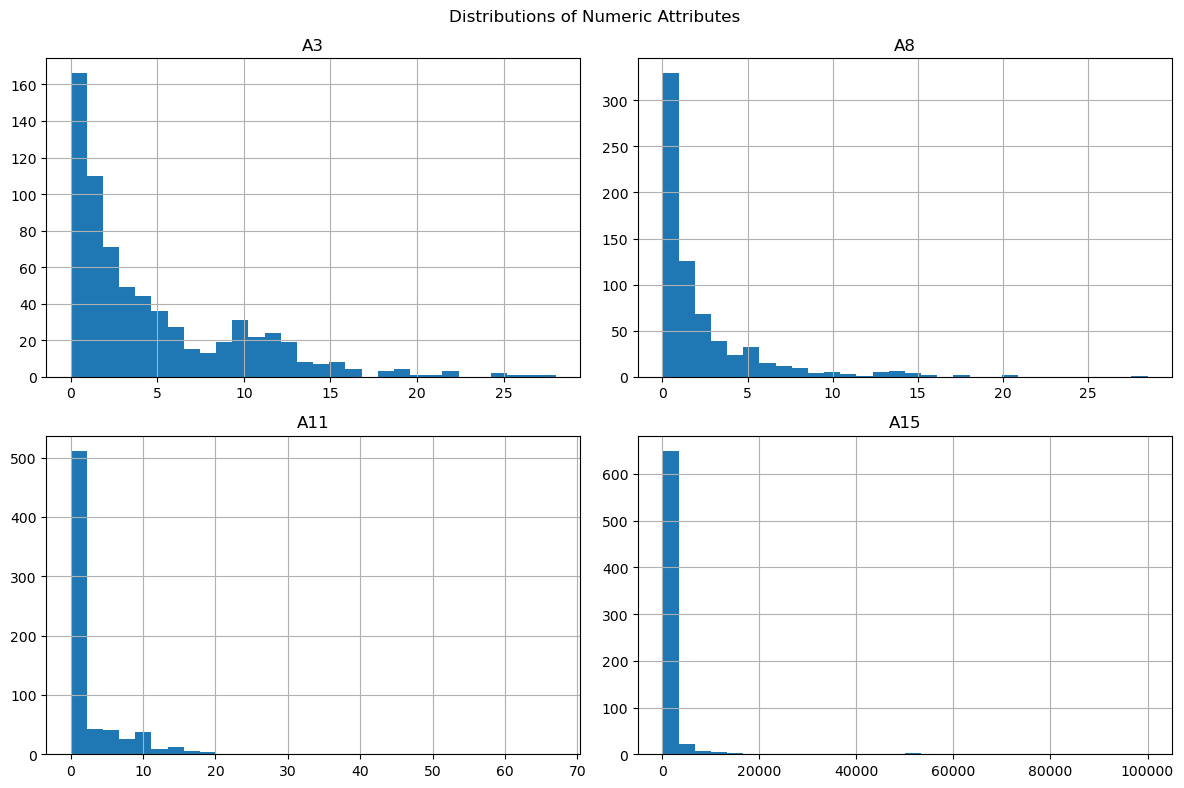

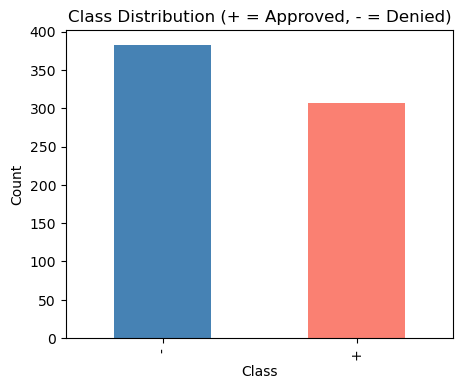

In [54]:
# Cell 5: Visualizations

# Separate numeric and categorical columns for convenience
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

# Histograms for numeric columns
Demo[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distributions of Numeric Attributes")
plt.tight_layout()
plt.show()

# Class balance (approved vs denied)
Demo['Class'].value_counts().plot(kind='bar', figsize=(5, 4), color=['steelblue', 'salmon'])
plt.title("Class Distribution (+ = Approved, - = Denied)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

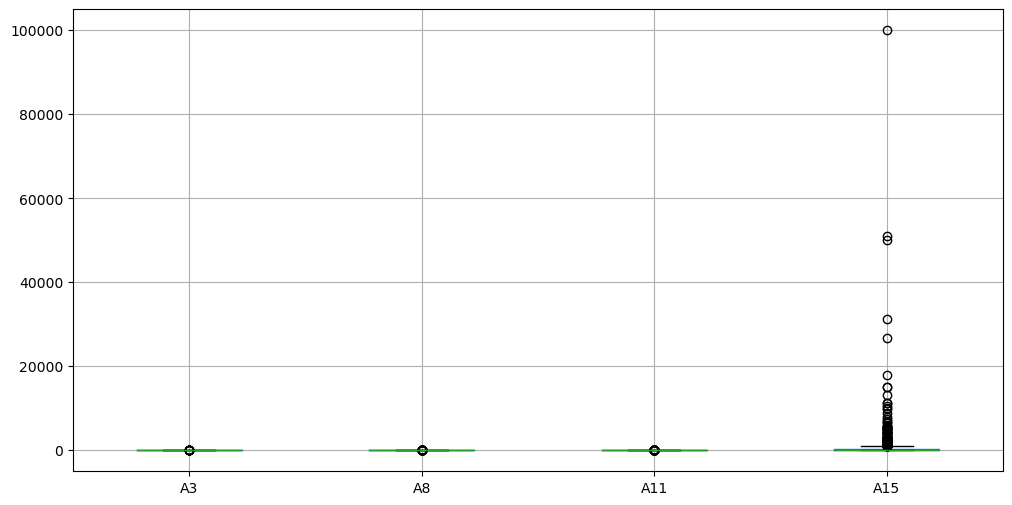

In [61]:
# Cell 6: Outlier detection with boxplots
#Boxplots to visually identify outliers in the numeric columns.
Demo.select_dtypes(include='number').boxplot(figsize=(12, 6))
plt.show()

In [64]:
# Cell 7: Handle missing values
# Numeric columns with missing values: A2, A14 -> fill with median (robust to skew)
# Categorical columns with missing values: A1, A4, A5, A6, A7 -> fill with mode
Demo = Demo.replace('?', np.nan)
numeric_missing = ['A2', 'A14']
categorical_missing = ['A1', 'A4', 'A5', 'A6', 'A7']

#Convert numeric columns to numeric data type
for col in numeric_missing:
    Demo[col] = pd.to_numeric(Demo[col], errors='coerce')

# Fill numeric missing values with median
for col in numeric_missing:
    Demo[col] = Demo[col].fillna(Demo[col].median())

# Fill categorical missing values with mode
for col in categorical_missing:
    Demo[col] = Demo[col].fillna(Demo[col].mode()[0])


# Confirm no missing values remain
print("Remaining missing values:\n", Demo.isnull().sum().sum())

Remaining missing values:
 0


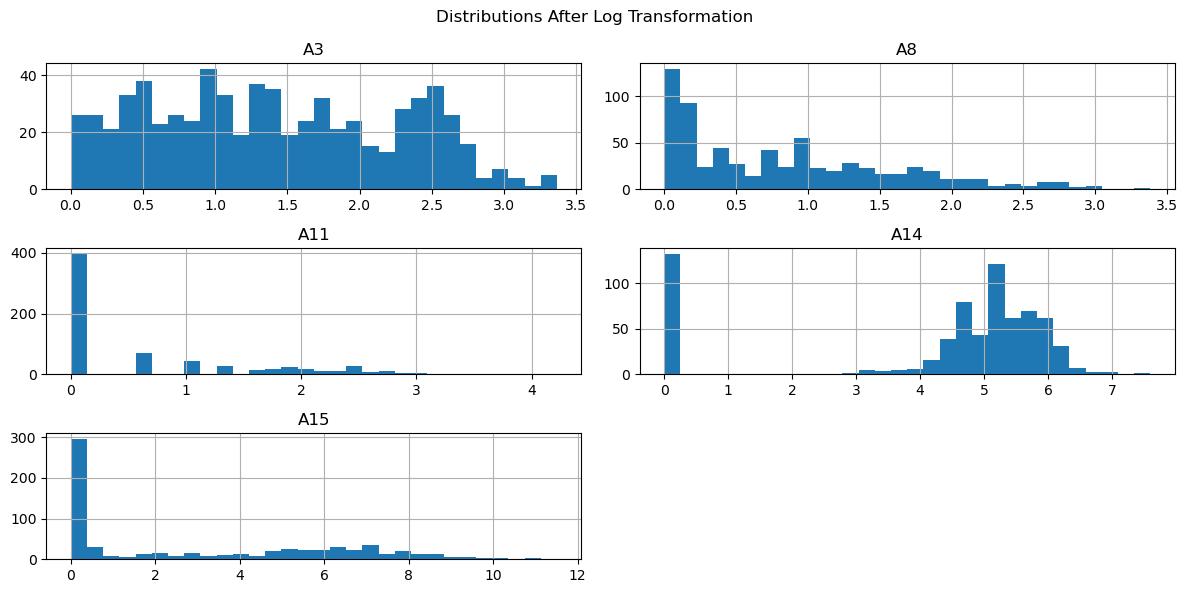

In [65]:
# Cell 8: Handle outliers via log transformation
# A3, A8, A11, A14, A15 are heavily right-skewed with many "outliers" by the IQR rule.
# Rather than deleting ~16% of rows (A15) or capping legitimate high values,
# we log-transform to compress the long tail while keeping every row.
# log1p (log(1+x)) is used instead of log() because these columns contain zeros,
# and log(0) is undefined.

skewed_cols = ['A3', 'A8', 'A11', 'A14', 'A15']

for col in skewed_cols:
    Demo[col] = np.log1p(Demo[col])

# Re-check the distributions after transformation
Demo[skewed_cols].hist(figsize=(12, 6), bins=30)
plt.suptitle("Distributions After Log Transformation")
plt.tight_layout()
plt.show()

In [66]:
# Quick check: how many categories does each categorical column have?
categorical_cols_all = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
for col in categorical_cols_all:
    print(f"{col}: {Demo[col].nunique()} unique values -> {Demo[col].unique()}")

A1: 2 unique values -> ['b' 'a']
A4: 3 unique values -> ['u' 'y' 'l']
A5: 3 unique values -> ['g' 'p' 'gg']
A6: 14 unique values -> ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j']
A7: 9 unique values -> ['v' 'h' 'bb' 'ff' 'j' 'z' 'o' 'dd' 'n']
A9: 2 unique values -> ['t' 'f']
A10: 2 unique values -> ['t' 'f']
A12: 2 unique values -> ['f' 't']
A13: 3 unique values -> ['g' 's' 'p']


In [67]:
# Cell 9: Label encode binary columns + target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['A1', 'A9', 'A10', 'A12']
for col in binary_cols:
    Demo[col] = le.fit_transform(Demo[col])

# Encode the target: '+' -> 1, '-' -> 0
Demo['Class'] = le.fit_transform(Demo['Class'])

Demo[binary_cols + ['Class']].head()

,A1,A9,A10,A12,Class
0,1,1,1,0,0
1,0,1,1,0,0
2,0,1,0,0,0
3,1,1,1,1,0
4,1,1,0,0,0


In [68]:
# Cell 10: One-hot encode multi-category columns
# These have no natural order, so LabelEncoder's 0,1,2,3... would wrongly
# imply an ordering. One-hot encoding gives each category its own column instead.

multi_cat_cols = ['A4', 'A5', 'A6', 'A7', 'A13']

Demo = pd.get_dummies(Demo, columns=multi_cat_cols, drop_first=True)

print("New shape after one-hot encoding:", Demo.shape)
Demo.head()

New shape after one-hot encoding: (690, 38)


,A1,A2,A3,A8,A9,A10,A11,A12,A14,A15,...,A7_dd,A7_ff,A7_h,A7_j,A7_n,A7_o,A7_v,A7_z,A13_p,A13_s
0,1,30.83,0.000000,0.810930,1,1,0.693147,0,5.313206,0.000000,...,False,False,False,False,False,False,True,False,False,False
1,0,58.67,1.697449,1.396245,1,1,1.945910,0,3.784190,6.329721,...,False,False,True,False,False,False,False,False,False,False
2,0,24.50,0.405465,0.916291,1,0,0.000000,0,5.638355,6.715383,...,False,False,True,False,False,False,False,False,False,False
3,1,27.83,0.932164,1.558145,1,1,1.791759,1,4.615121,1.386294,...,False,False,False,False,False,False,True,False,False,False
4,1,20.17,1.890850,0.996949,1,0,0.000000,0,4.795791,0.000000,...,False,False,False,False,False,False,True,False,False,True


In [70]:
# Cell 11: Scale numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

scaler = StandardScaler()
Demo[numeric_cols] = scaler.fit_transform(Demo[numeric_cols])

Demo[numeric_cols].describe()

,A2,A3,A8,A11,A14,A15
count,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02
mean,2.111033e-16,-4.119088e-17,4.119088e-17,2.059544e-17,-1.184238e-16,1.338704e-16
std,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00
min,-1.498873e+00,-1.669101e+00,-1.108830e+00,-7.401174e-01,-1.975151e+00,-9.328970e-01
25%,-7.462352e-01,-8.443561e-01,-9.062748e-01,-7.401174e-01,8.009852e-02,-9.328970e-01
50%,-2.576955e-01,-9.640245e-02,-1.895024e-01,-7.401174e-01,4.013821e-01,-3.705328e-01
75%,5.225758e-01,8.355546e-01,5.992634e-01,7.544921e-01,6.483550e-01,9.448334e-01
max,4.112161e+00,2.337495e+00,3.379920e+00,3.809072e+00,1.579965e+00,2.680569e+00


In [72]:
# Cell 12: Train/test split
from sklearn.model_selection import train_test_split

X = Demo.drop(columns=['Class'])
y = Demo['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (552, 37)
Test shape: (138, 37)

Train class balance:
 Class
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Test class balance:
 Class
1    0.557971
0    0.442029
Name: proportion, dtype: float64


In [74]:
# Cell 13: Build the classifier (Logistic Regression)
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

Logistic Regression Accuracy: 0.8406
Logistic Regression F1-score: 0.8533


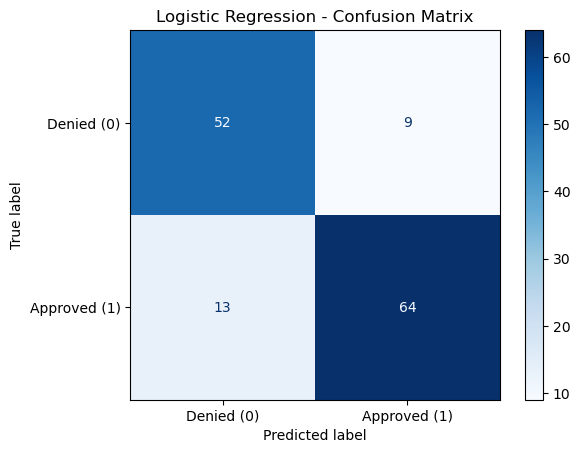

In [75]:
# Cell 14: Evaluate with two metrics — Accuracy and F1-score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

log_accuracy = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print(f"Logistic Regression F1-score: {log_f1:.4f}")

cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied (0)', 'Approved (1)'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

The Logistic Regression model correctly classified about 84% of the observations. The F1-score of 85.33% shows that the model has a good balance between precision and recall for identifying approved applications. I selected accuracy because it gives an overall measure of correct predictions, while F1-score was selected because it considers both false positives and false negatives.